In [142]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import nltk
import spacy
from bs4 import BeautifulSoup
import contractions


# Gensim (LDA)
import scipy
import gensim
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel

# Sklearn (LSA, NMF, TF-IDF)
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.preprocessing import Normalizer

# Visualization
from wordcloud import WordCloud
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords

# spaCy model
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    import subprocess
    subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'])
    nlp = spacy.load('en_core_web_sm')

print('✅ All imports successful')

✅ All imports successful


In [143]:
#Retrieve the dataset without having to import the dataset again

%store -r disneyland_df

In [144]:
disneyland_df

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,review_cleaned,clean_review_wo_stopwords,tokenized_texts,cleaned_texts
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,if you have ever been to disneyland anywhere y...,ever anywhere find similar layout walk main st...,"[ever, anywhere, find, similar, layout, walk, ...",ever anywhere find similar layout walk main st...
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,its been a while since d last time we visit hk...,since last visit hk yet stay tomorrowland aka ...,"[since, last, visit, yet, stay, tomorrowland, ...",since last visit yet stay tomorrowland aka mar...
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,thanks god it wasn t too hot or too humid when...,thanks god hot humid visiting otherwise big is...,"[thank, god, hot, humid, visit, otherwise, big...",thank god hot humid visit otherwise big issue ...
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,hk disneyland is a great compact park unfortu...,hk great compact unfortunately bit maintenance...,"[great, compact, unfortunately, bit, maintenan...",great compact unfortunately bit maintenance wo...
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,the location is not in the city took around ...,location city around hour kowlon kids everythi...,"[location, city, around, hour, kowlon, kid, ev...",location city around hour kowlon kid everythin...
...,...,...,...,...,...,...,...,...,...,...
42651,1765031,5,missing,United Kingdom,i went to disneyland paris in july 03 and thou...,Disneyland_Paris,i went to disneyland paris in july and thou...,july thought brilliant visited hotels stayed n...,"[july, brilliant, visit, hotel, stay, newport,...",july brilliant visit hotel stay newport bay ky...
42652,1659553,5,missing,Canada,2 adults and 1 child of 11 visited Disneyland ...,Disneyland_Paris,adults and child of visited disneyland ...,adults child visited beginning feb absolute fa...,"[adult, child, visit, begin, feb, absolute, fa...",adult child visit begin feb absolute fantastic...
42653,1645894,5,missing,South Africa,My eleven year old daughter and myself went to...,Disneyland_Paris,my eleven year old daughter and myself went to...,eleven year old daughter visit son london deci...,"[eleven, year, old, daughter, visit, son, lond...",eleven year old daughter visit son london deci...
42654,1618637,4,missing,United States,"This hotel, part of the Disneyland Paris compl...",Disneyland_Paris,this hotel part of the disneyland paris compl...,hotel part complex wonderful place families si...,"[hotel, part, complex, wonderful, place, famil...",hotel part complex wonderful place family sinc...


In [ ]:
#Break Down the Different Categories
california_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_California']
hong_kong_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_HongKong']
paris_reviews=disneyland_df[disneyland_df['Branch']=='Disneyland_Paris']

In [145]:
tokenized_texts=disneyland_df['tokenized_texts']

In [146]:
# Gensim Dictionary: maps each unique token to an integer ID
dictionary = Dictionary(tokenized_texts)

# Filter extremes: remove tokens that appear in <5 docs or >80% of docs
dictionary.filter_extremes(no_below=5, no_above=0.80)

# Bag-of-Words corpus: list of (token_id, count) per document
bow_corpus = [dictionary.doc2bow(text) for text in tokenized_texts]

print(f'Vocabulary size: {len(dictionary):,} unique tokens')
print(f'Corpus size:     {len(bow_corpus):,} documents')
print()
print('Example — first document as BoW (first 8 pairs):')
print(bow_corpus[0][:8])
print()
print('Decoded:')
print([(dictionary[wid], cnt) for wid, cnt in bow_corpus[0][:8]])

Vocabulary size: 9,025 unique tokens
Corpus size:     42,478 documents

Example — first document as BoW (first 8 pairs):
[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 2), (6, 1), (7, 1)]

Decoded:
[('absolutely', 1), ('anywhere', 1), ('busy', 1), ('ever', 1), ('fabulous', 1), ('fairly', 2), ('familiar', 1), ('find', 1)]


In [174]:
bow_corpus

[[(0, 1),
  (1, 1),
  (2, 1),
  (3, 1),
  (4, 1),
  (5, 2),
  (6, 1),
  (7, 1),
  (8, 1),
  (9, 1),
  (10, 1),
  (11, 1),
  (12, 1),
  (13, 1),
  (14, 1),
  (15, 1),
  (16, 1),
  (17, 1),
  (18, 1),
  (19, 1),
  (20, 1),
  (21, 1),
  (22, 1)],
 [(10, 1),
  (17, 1),
  (18, 1),
  (23, 1),
  (24, 1),
  (25, 1),
  (26, 1),
  (27, 1),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 1),
  (32, 2),
  (33, 1),
  (34, 1),
  (35, 1),
  (36, 1),
  (37, 1),
  (38, 1),
  (39, 1),
  (40, 1),
  (41, 1),
  (42, 1),
  (43, 1),
  (44, 1),
  (45, 1),
  (46, 1),
  (47, 2),
  (48, 1),
  (49, 1),
  (50, 1),
  (51, 1),
  (52, 1),
  (53, 1),
  (54, 1),
  (55, 1),
  (56, 2),
  (57, 1),
  (58, 1),
  (59, 1),
  (60, 1),
  (61, 2),
  (62, 1),
  (63, 1),
  (64, 1),
  (65, 1),
  (66, 1),
  (67, 1),
  (68, 1),
  (69, 1),
  (70, 2),
  (71, 1),
  (72, 1),
  (73, 1),
  (74, 1),
  (75, 1),
  (76, 1),
  (77, 1),
  (78, 1),
  (79, 1),
  (80, 1),
  (81, 1),
  (82, 2),
  (83, 1),
  (84, 1),
  (85, 1),
  (86, 1),
  (87, 1),
  (88, 1

In [147]:
# ── Coherence over a range of k ─────────────────────────────────
# WARNING: this cell may take 2-5 minutes depending on machine

K_RANGE = [5, 8, 10, 12, 15]
coherence_scores = []
perplexity_scores = []

for k in K_RANGE:
    model = LdaModel(
        corpus=bow_corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=5,           # lower for speed during search
        chunksize=200,
        alpha='symmetric',
        eta='auto'
    )
    # Coherence (C_v) — higher is better
    cm = CoherenceModel(
        model=model, texts=tokenized_texts,
        dictionary=dictionary, coherence='c_v'
    )
    coherence_scores.append(cm.get_coherence())

    # Perplexity — lower is better
    perplexity_scores.append(np.exp(-model.log_perplexity(bow_corpus)))

print('k   Coherence  Perplexity')
print('─' * 30)
for k, c, p in zip(K_RANGE, coherence_scores, perplexity_scores):
    print(f'{k:2d}  {c:.4f}     {p:.1f}')

k   Coherence  Perplexity
──────────────────────────────
 5  0.4296     1338.6
 8  0.4265     1478.3
10  0.4084     1809.5
12  0.4020     3319.6
15  0.4287     22497.5


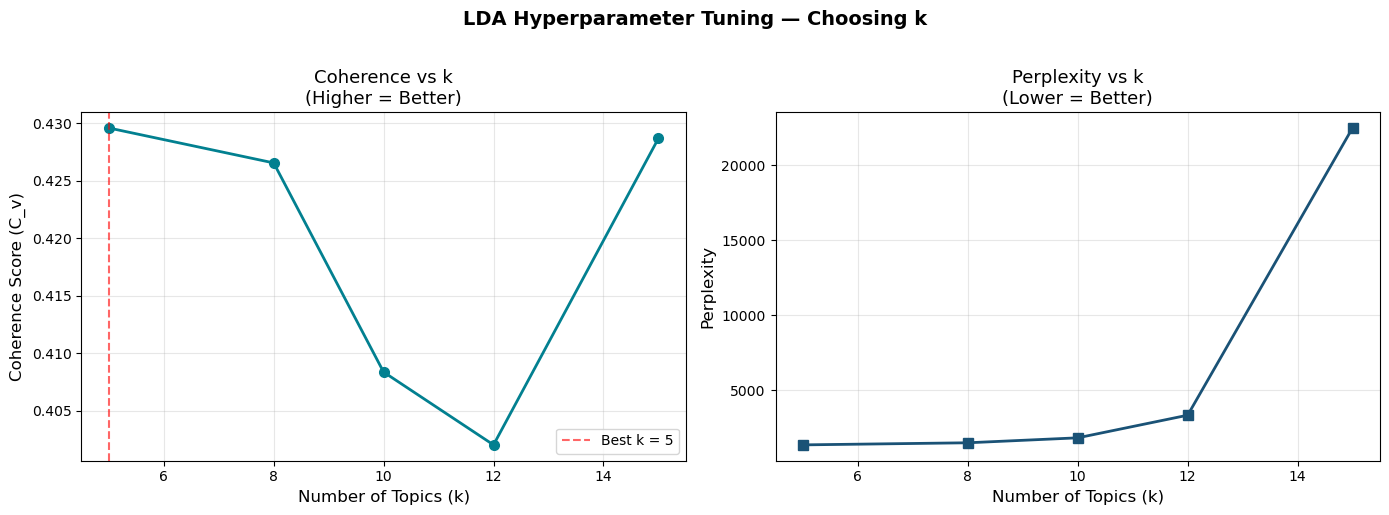

Best k by coherence: 5
Max coherence score: 0.4296


In [148]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Coherence
ax1.plot(list(K_RANGE), coherence_scores, 'o-', color='#028090', linewidth=2, markersize=7)
ax1.set_xlabel('Number of Topics (k)', fontsize=12)
ax1.set_ylabel('Coherence Score (C_v)', fontsize=12)
ax1.set_title('Coherence vs k\n(Higher = Better)', fontsize=13)
ax1.axvline(x=K_RANGE[coherence_scores.index(max(coherence_scores))],
            color='red', linestyle='--', alpha=0.6,
            label=f'Best k = {K_RANGE[coherence_scores.index(max(coherence_scores))]}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Perplexity
ax2.plot(list(K_RANGE), perplexity_scores, 's-', color='#1A5276', linewidth=2, markersize=7)
ax2.set_xlabel('Number of Topics (k)', fontsize=12)
ax2.set_ylabel('Perplexity', fontsize=12)
ax2.set_title('Perplexity vs k\n(Lower = Better)', fontsize=13)
ax2.grid(True, alpha=0.3)

plt.suptitle('LDA Hyperparameter Tuning — Choosing k', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("LDA_hyperparameter_tuning.png")
plt.show()

best_k = K_RANGE[coherence_scores.index(max(coherence_scores))]
print(f'Best k by coherence: {best_k}')
print(f'Max coherence score: {max(coherence_scores):.4f}')

In [149]:
NUM_TOPICS = 5  # Change this based on elbow chart

lda_model = LdaModel(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=15,           # more passes → better convergence
    chunksize=200,
    alpha='auto',        # auto-tune doc-topic sparsity
    eta='auto'           # auto-tune topic-word sparsity
)
print(f'✅ LDA model trained with k={NUM_TOPICS}')

✅ LDA model trained with k=5


In [150]:
print('=== LDA Topic-Word Distributions ===\n')
for i in range(NUM_TOPICS):
    words = lda_model.show_topic(i, topn=20)
    word_str = '  |  '.join([f'{w} ({p:.3f})' for w, p in words])
    print(f'Topic {i+1}: {word_str}')
    print()

=== LDA Topic-Word Distributions ===

Topic 1: child (0.029)  |  great (0.029)  |  kid (0.028)  |  visit (0.025)  |  year (0.024)  |  good (0.024)  |  parade (0.021)  |  place (0.021)  |  show (0.020)  |  character (0.018)  |  love (0.018)  |  old (0.017)  |  rid (0.016)  |  well (0.016)  |  enjoy (0.015)  |  family (0.012)  |  worth (0.012)  |  little (0.012)  |  fun (0.012)  |  trip (0.011)

Topic 2: euro (0.022)  |  village (0.012)  |  tell (0.012)  |  leave (0.011)  |  people (0.010)  |  push (0.009)  |  cafe (0.009)  |  member (0.009)  |  give (0.009)  |  front (0.009)  |  service (0.009)  |  ask (0.008)  |  sit (0.008)  |  stop (0.008)  |  rude (0.008)  |  outside (0.008)  |  speak (0.007)  |  area (0.007)  |  main (0.007)  |  way (0.007)

Topic 3: hotel (0.053)  |  stay (0.033)  |  ticket (0.028)  |  eat (0.021)  |  book (0.018)  |  meal (0.016)  |  buy (0.015)  |  restaurant (0.013)  |  drink (0.013)  |  breakfast (0.013)  |  train (0.012)  |  room (0.011)  |  want (0.011)  |  

In [151]:
# ── Evaluate final model ─────────────────────────────────────────
cm_final = CoherenceModel(
    model=lda_model, texts=tokenized_texts,
    dictionary=dictionary, coherence='c_v'
)
coherence_final = cm_final.get_coherence()
perplexity_final = np.exp(-lda_model.log_perplexity(bow_corpus))

print(f'Final Coherence (C_v): {coherence_final:.4f}  (higher = better)')
print(f'Final Perplexity:      {perplexity_final:.2f}  (lower  = better)')

Final Coherence (C_v): 0.4122  (higher = better)
Final Perplexity:      1288.20  (lower  = better)


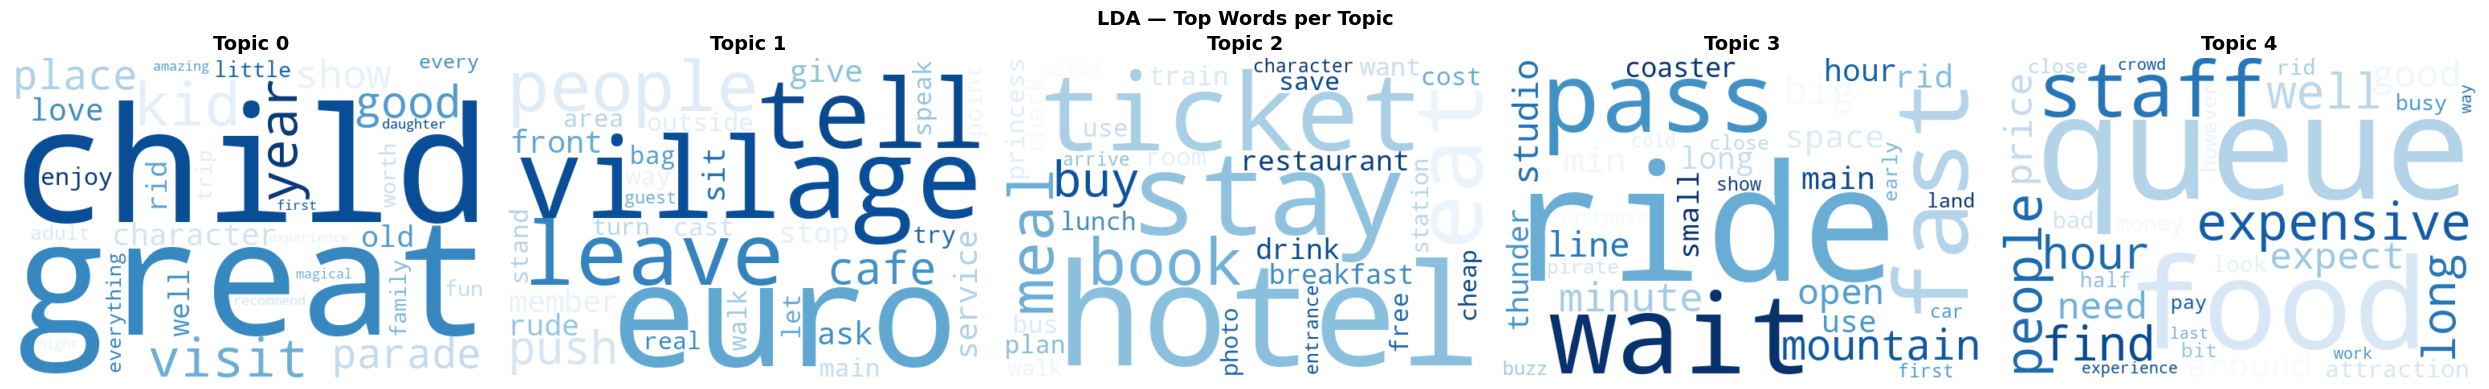

In [152]:
fig, axes = plt.subplots(1, NUM_TOPICS, figsize=(5 * NUM_TOPICS, 4))
lda_topic_words = {}

for topic_idx in range(NUM_TOPICS):
    word_weights = dict(lda_model.show_topic(topic_idx, topn=30))
    lda_topic_words[f'Topic {topic_idx}'] = list(word_weights.keys())[:10]

    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='Blues'
    ).generate_from_frequencies(word_weights)

    axes[topic_idx].imshow(wc, interpolation='bilinear')
    axes[topic_idx].axis('off')
    axes[topic_idx].set_title(f'Topic {topic_idx}', fontsize=14, fontweight='bold')

plt.suptitle('LDA — Top Words per Topic', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("word_cloud_comparison.png")
plt.show()

In [153]:
def get_doc_topic_df(model, corpus, n_topics):
    """Return a DataFrame of topic probabilities per document."""
    rows = []
    for doc in corpus:
        dist = dict(model.get_document_topics(doc, minimum_probability=0))
        rows.append([dist.get(i, 0.0) for i in range(n_topics)])
    return pd.DataFrame(rows, columns=[f'Topic_{i}' for i in range(n_topics)])

doc_topic_df = get_doc_topic_df(lda_model, bow_corpus, NUM_TOPICS)
doc_topic_df.head(8).round(3)

,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4
0,0.253,0.064,0.057,0.336,0.289
1,0.269,0.167,0.053,0.206,0.305
2,0.290,0.068,0.049,0.120,0.473
3,0.187,0.049,0.138,0.130,0.496
4,0.263,0.155,0.118,0.139,0.325
5,0.165,0.192,0.142,0.083,0.419
6,0.411,0.080,0.083,0.116,0.309
7,0.122,0.280,0.097,0.156,0.344


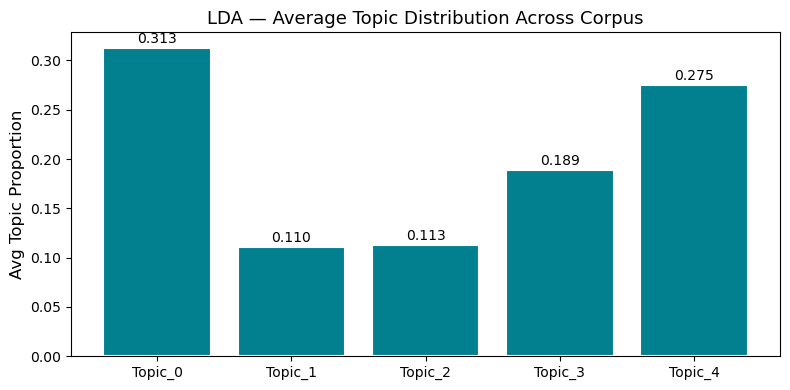

In [154]:
# Average topic proportion across corpus
avg = doc_topic_df.mean()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(avg.index, avg.values, color='#028090', edgecolor='white', linewidth=1.5)
ax.set_ylabel('Avg Topic Proportion', fontsize=12)
ax.set_title('LDA — Average Topic Distribution Across Corpus', fontsize=13)
for bar, val in zip(bars, avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig("lda_avg_topic_distribution.png")
plt.show()

In [155]:
# What is the dominant topic for each document?
doc_topic_df['dominant_topic'] = doc_topic_df.iloc[:, :NUM_TOPICS].idxmax(axis=1)

# Sample: show a few docs and their dominant topic
sample = doc_topic_df[['dominant_topic']].copy()
sample['text_preview'] = [d[:80] + '...' for d in disneyland_df['cleaned_texts'][:len(sample)]]
print(sample.head(10).to_string())

print(f'\nTopic distribution across documents:')
print(doc_topic_df['dominant_topic'].value_counts())

  dominant_topic                                                                         text_preview
0        Topic_3  ever anywhere find similar layout walk main street familiar rid small world abso...
1        Topic_4  since last visit yet stay tomorrowland aka marvel land iron man experience newly...
2        Topic_4  thank god hot humid visit otherwise big issue shade arrive around leave unfortun...
3        Topic_4  great compact unfortunately bit maintenance work present number area close inclu...
4        Topic_4                    location city around hour kowlon kid everything fine crowd hot...
5        Topic_4  world small call way rid attraction souvenir food entrance ticket slightly expen...
6        Topic_0                  great place obviously daughter absolutely love bad parade cancel...
7        Topic_4  intro magic little attraction complete drawback timing example storybook theatre...
8        Topic_4  let place train fantastic past station bad signage terrible staf

In [156]:
# ── pyLDAvis — run in Jupyter for interactive chart ──────────────
# Left panel:  circles = topics; size = prevalence; spacing = distinctiveness
# Right panel: word bars for selected topic
# λ slider:    0 = most unique words; 1 = most frequent; try λ = 0.6

pyLDAvis.enable_notebook()
lda_vis = gensimvis.prepare(lda_model, bow_corpus, dictionary, sort_topics=False)
pyLDAvis.save_html(lda_vis, 'lda_visualization.html')
pyLDAvis.display(lda_vis)

In [157]:
# After inspecting pyLDAvis and word clouds, assign human-readable names
# ADJUST THESE based on your actual output words
TOPIC_NAMES = {
    'Topic 0': 'Space & Astronomy',
    'Topic 1': 'Baseball & Sports',
    'Topic 2': 'Gun Politics & Rights',
    'Topic 3': 'Computer Graphics & Tech',
}
print('Topic Names:')
for k, v in TOPIC_NAMES.items():
    top_words = ', '.join(lda_topic_words[k][:6])
    print(f'  {k} → {v:30s}  ({top_words})')

Topic Names:
  Topic 0 → Space & Astronomy               (child, great, kid, visit, year, good)
  Topic 1 → Baseball & Sports               (euro, village, tell, leave, people, push)
  Topic 2 → Gun Politics & Rights           (hotel, stay, ticket, eat, book, meal)
  Topic 3 → Computer Graphics & Tech        (ride, wait, fast, pass, mountain, minute)
